In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1440
#runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp4_fixgaussian20_50GW" # _nG30"

student = "Grating_Entire"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 663204
Average function evaluations per core: 3316


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
from scipy.optimize import minimize
from parameters import D1_ND

def get_final(l_min, l_max):
    doppler = l_min / l_max

    def test(v):
        v = v/100
        return np.abs(doppler - D1_ND(v))

    sol = minimize(test, 5)
    final_speed = sol.x[0]
    return final_speed

In [4]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 0

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6418, dtype=torch.float64), tensor(0.3615, dtype=torch.float64), tensor(0.3204, dtype=torch.float64), tensor(0.0493, dtype=torch.float64), tensor(0.7138, dtype=torch.float64), tensor(5.9201, dtype=torch.float64), tensor(10.3254, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.4276, dtype=torch.float64), tensor(4.6128, dtype=torch.float64)]
[tensor(1.6418, dtype=torch.float64), tensor(0.3615, dtype=torch.float64), tensor(0.3204, dtype=torch.float64), tensor(0.0493, dtype=torch.float64), tensor(0.7138, dtype=torch.float64), tensor(5.9201, dtype=torch.float64), tensor(10.3254, dtype=torch.float64), tensor(0.4276, dtype=torch.float64), tensor(4.6128, dtype=torch.float64)]
0.00013409468410318737
grating_pitch   = 1.6418416786639507
grating_depth   = 0.36145879601148656
box1_width      = 0.32036815778546013
box2_width      = 0.04933499531359043
b

In [5]:
class solution:
    def __init__(self, grating, eigvals, FOM):
        self.grating = grating
        self.FOM = FOM
        self.eigvals = eigvals

In [6]:
num_plot_points = 500

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating.wavelength = grating.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals(J1)
    
grating.wavelength = init_wavelength
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()

grating_1 = solution(grating, eigvals, average_fom)

C:\Users\Shaurya\AppData\Local\Temp\ipykernel_35668\1816513928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_35668\1816513928.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)


<Figure size 1500x750 with 0 Axes>

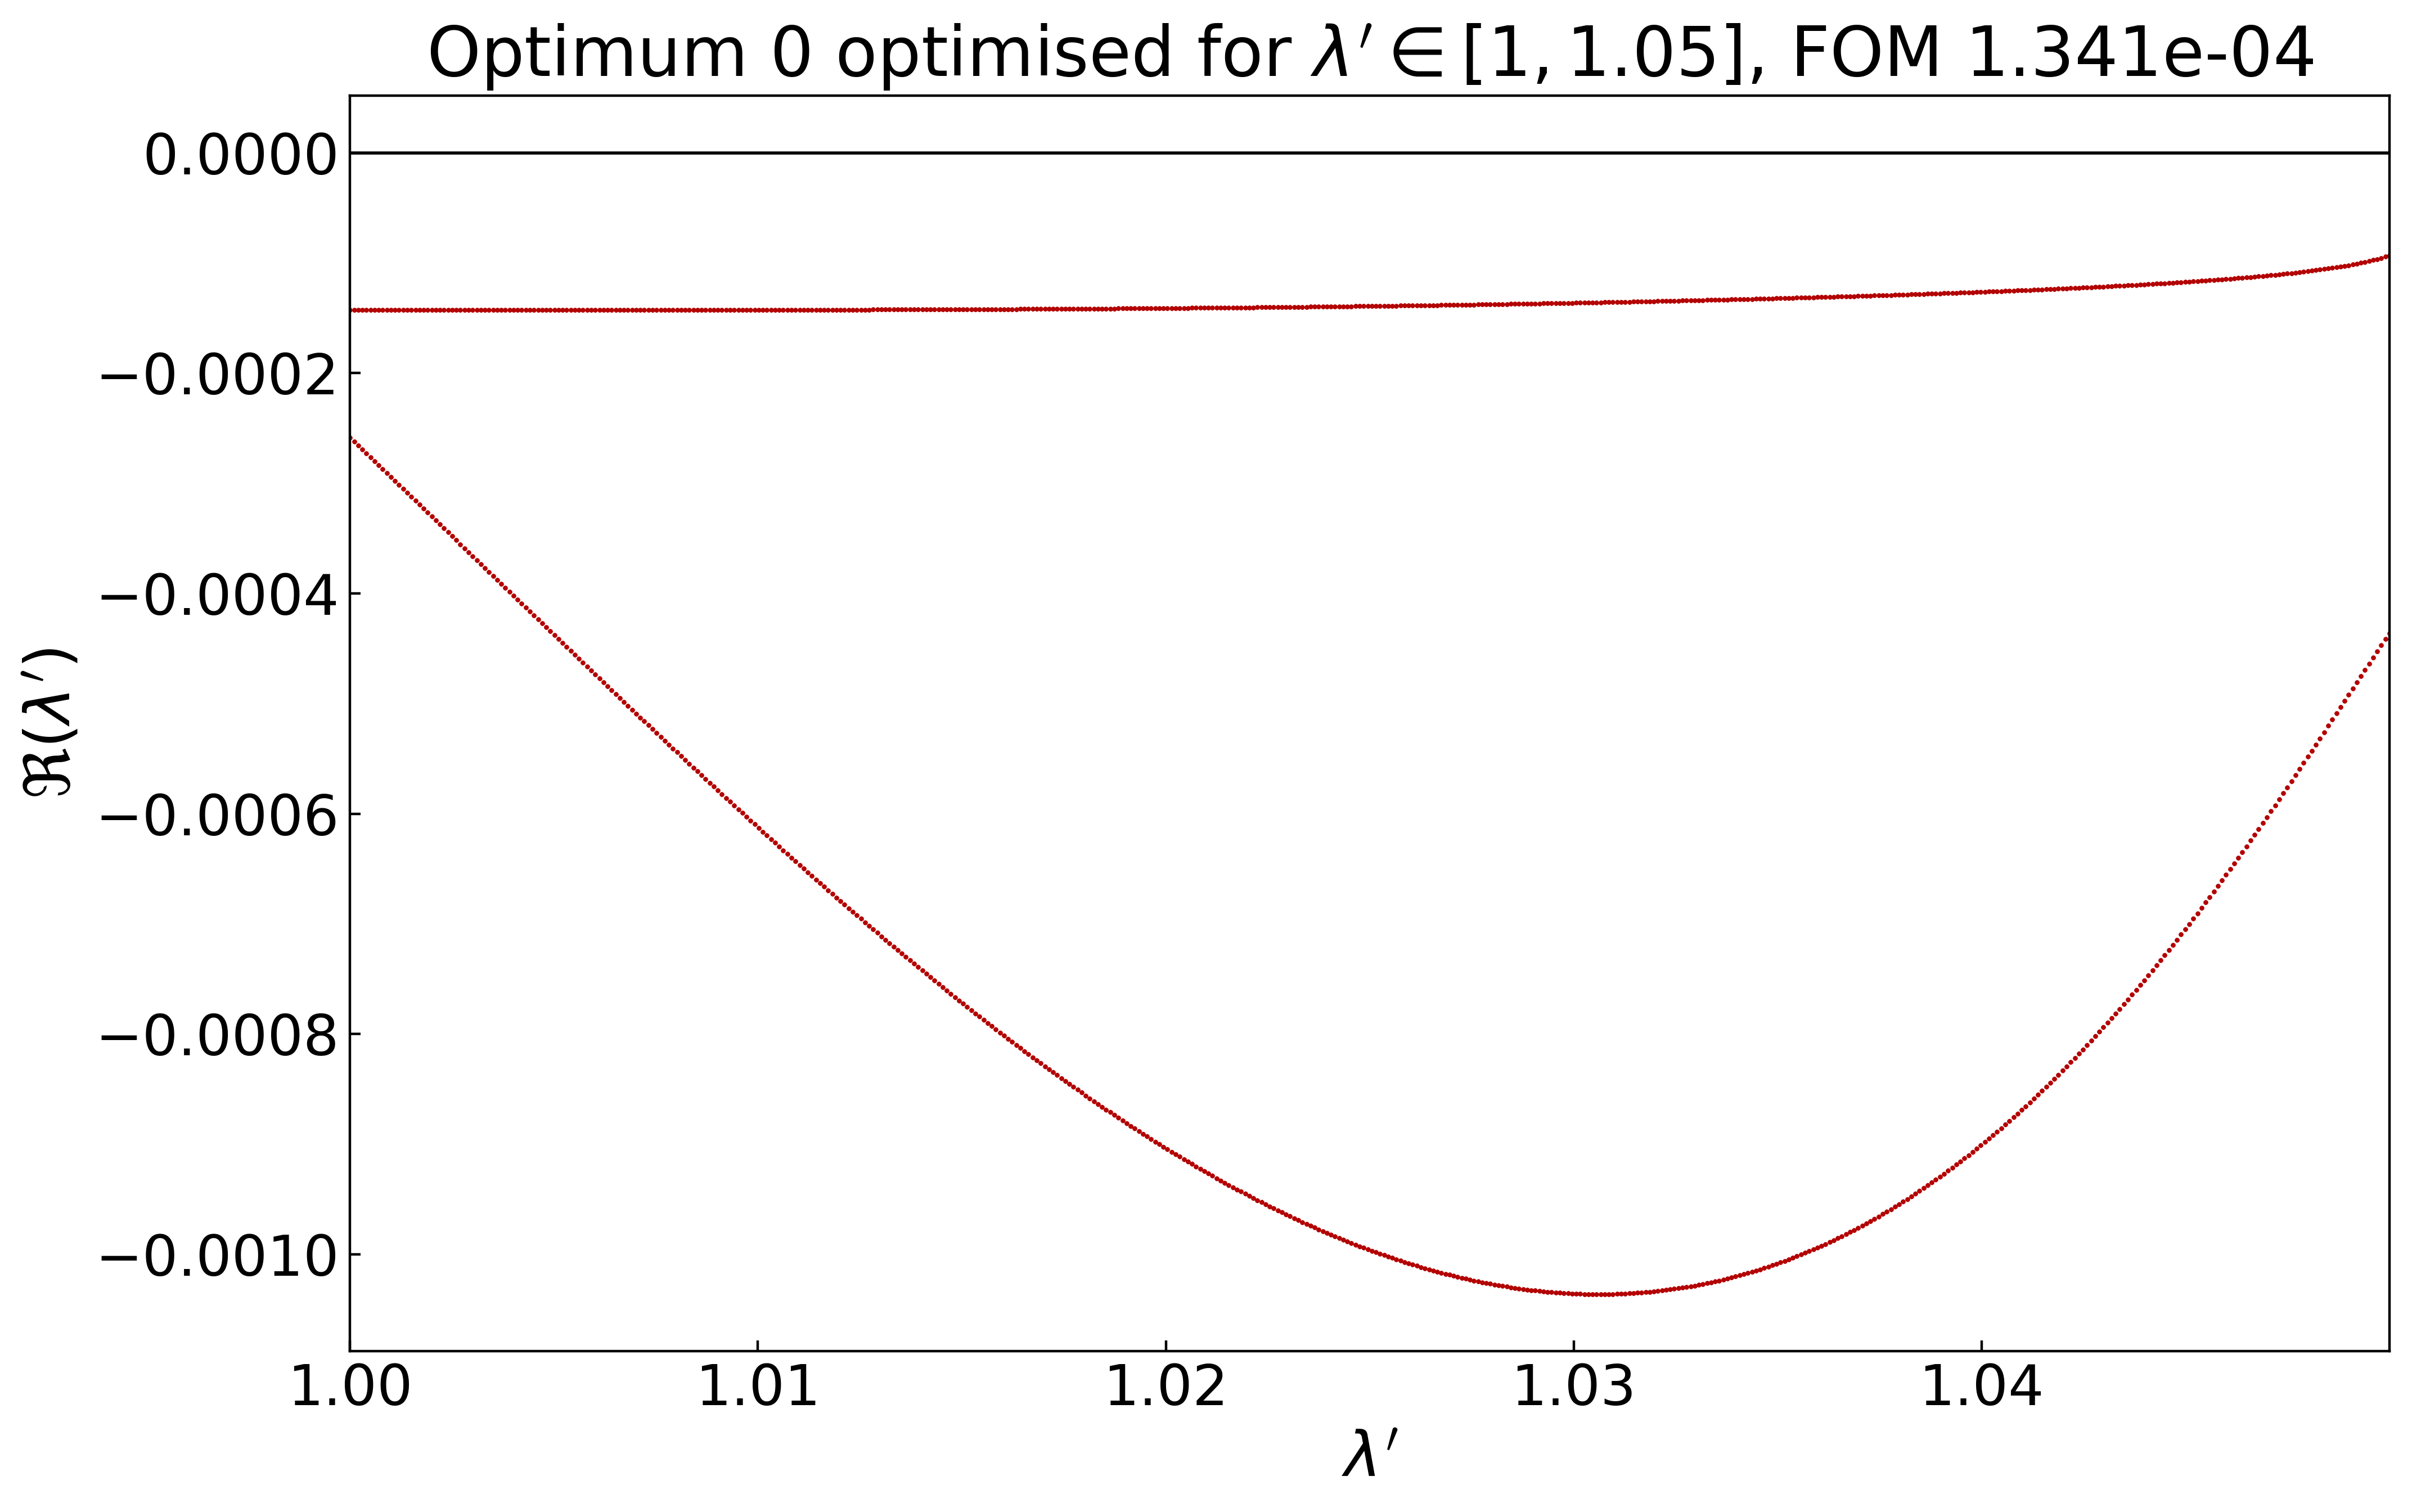

In [7]:
import matplotlib.pyplot as plt
plt.clf()
fig, ax1 = plt.subplots(figsize=(11, 7), nrows=1, ncols=1, dpi = 400)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$", fontsize=20)  #color=colorReal  # colored y label
ax1.set_xlabel(xlabel=r"$\lambda'$",fontsize=20)

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(grating_1.eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)

ax1.set_title(f"Optimum {optimum_number} optimised for $\\lambda' \\in [1, 1.05]$, FOM {np.format_float_scientific(grating_1.FOM, precision= 3)}", fontsize=22)

fig.tight_layout()
fig.savefig("optimum_0_entire.png")

In [8]:
I0, L, m, c = parameters.Parameters()
optimum_number = 6

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
0.00010308432310993768
grating_pitch   = 1.6396761254348513
grating_depth   = 0.44432874487544616
box1_width      = 0.34055202066710755
box2_width      = 0.05110622337224755
b

In [9]:
num_plot_points = 500

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating.wavelength = grating.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals(J1)
    
grating.wavelength = init_wavelength
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()

grating_2 = solution(grating, eigvals, average_fom)

Text(0.5, 1.0, "Optimum 6, optimised for $\\lambda' \\in [1, 1.05]$")

<Figure size 1500x750 with 0 Axes>

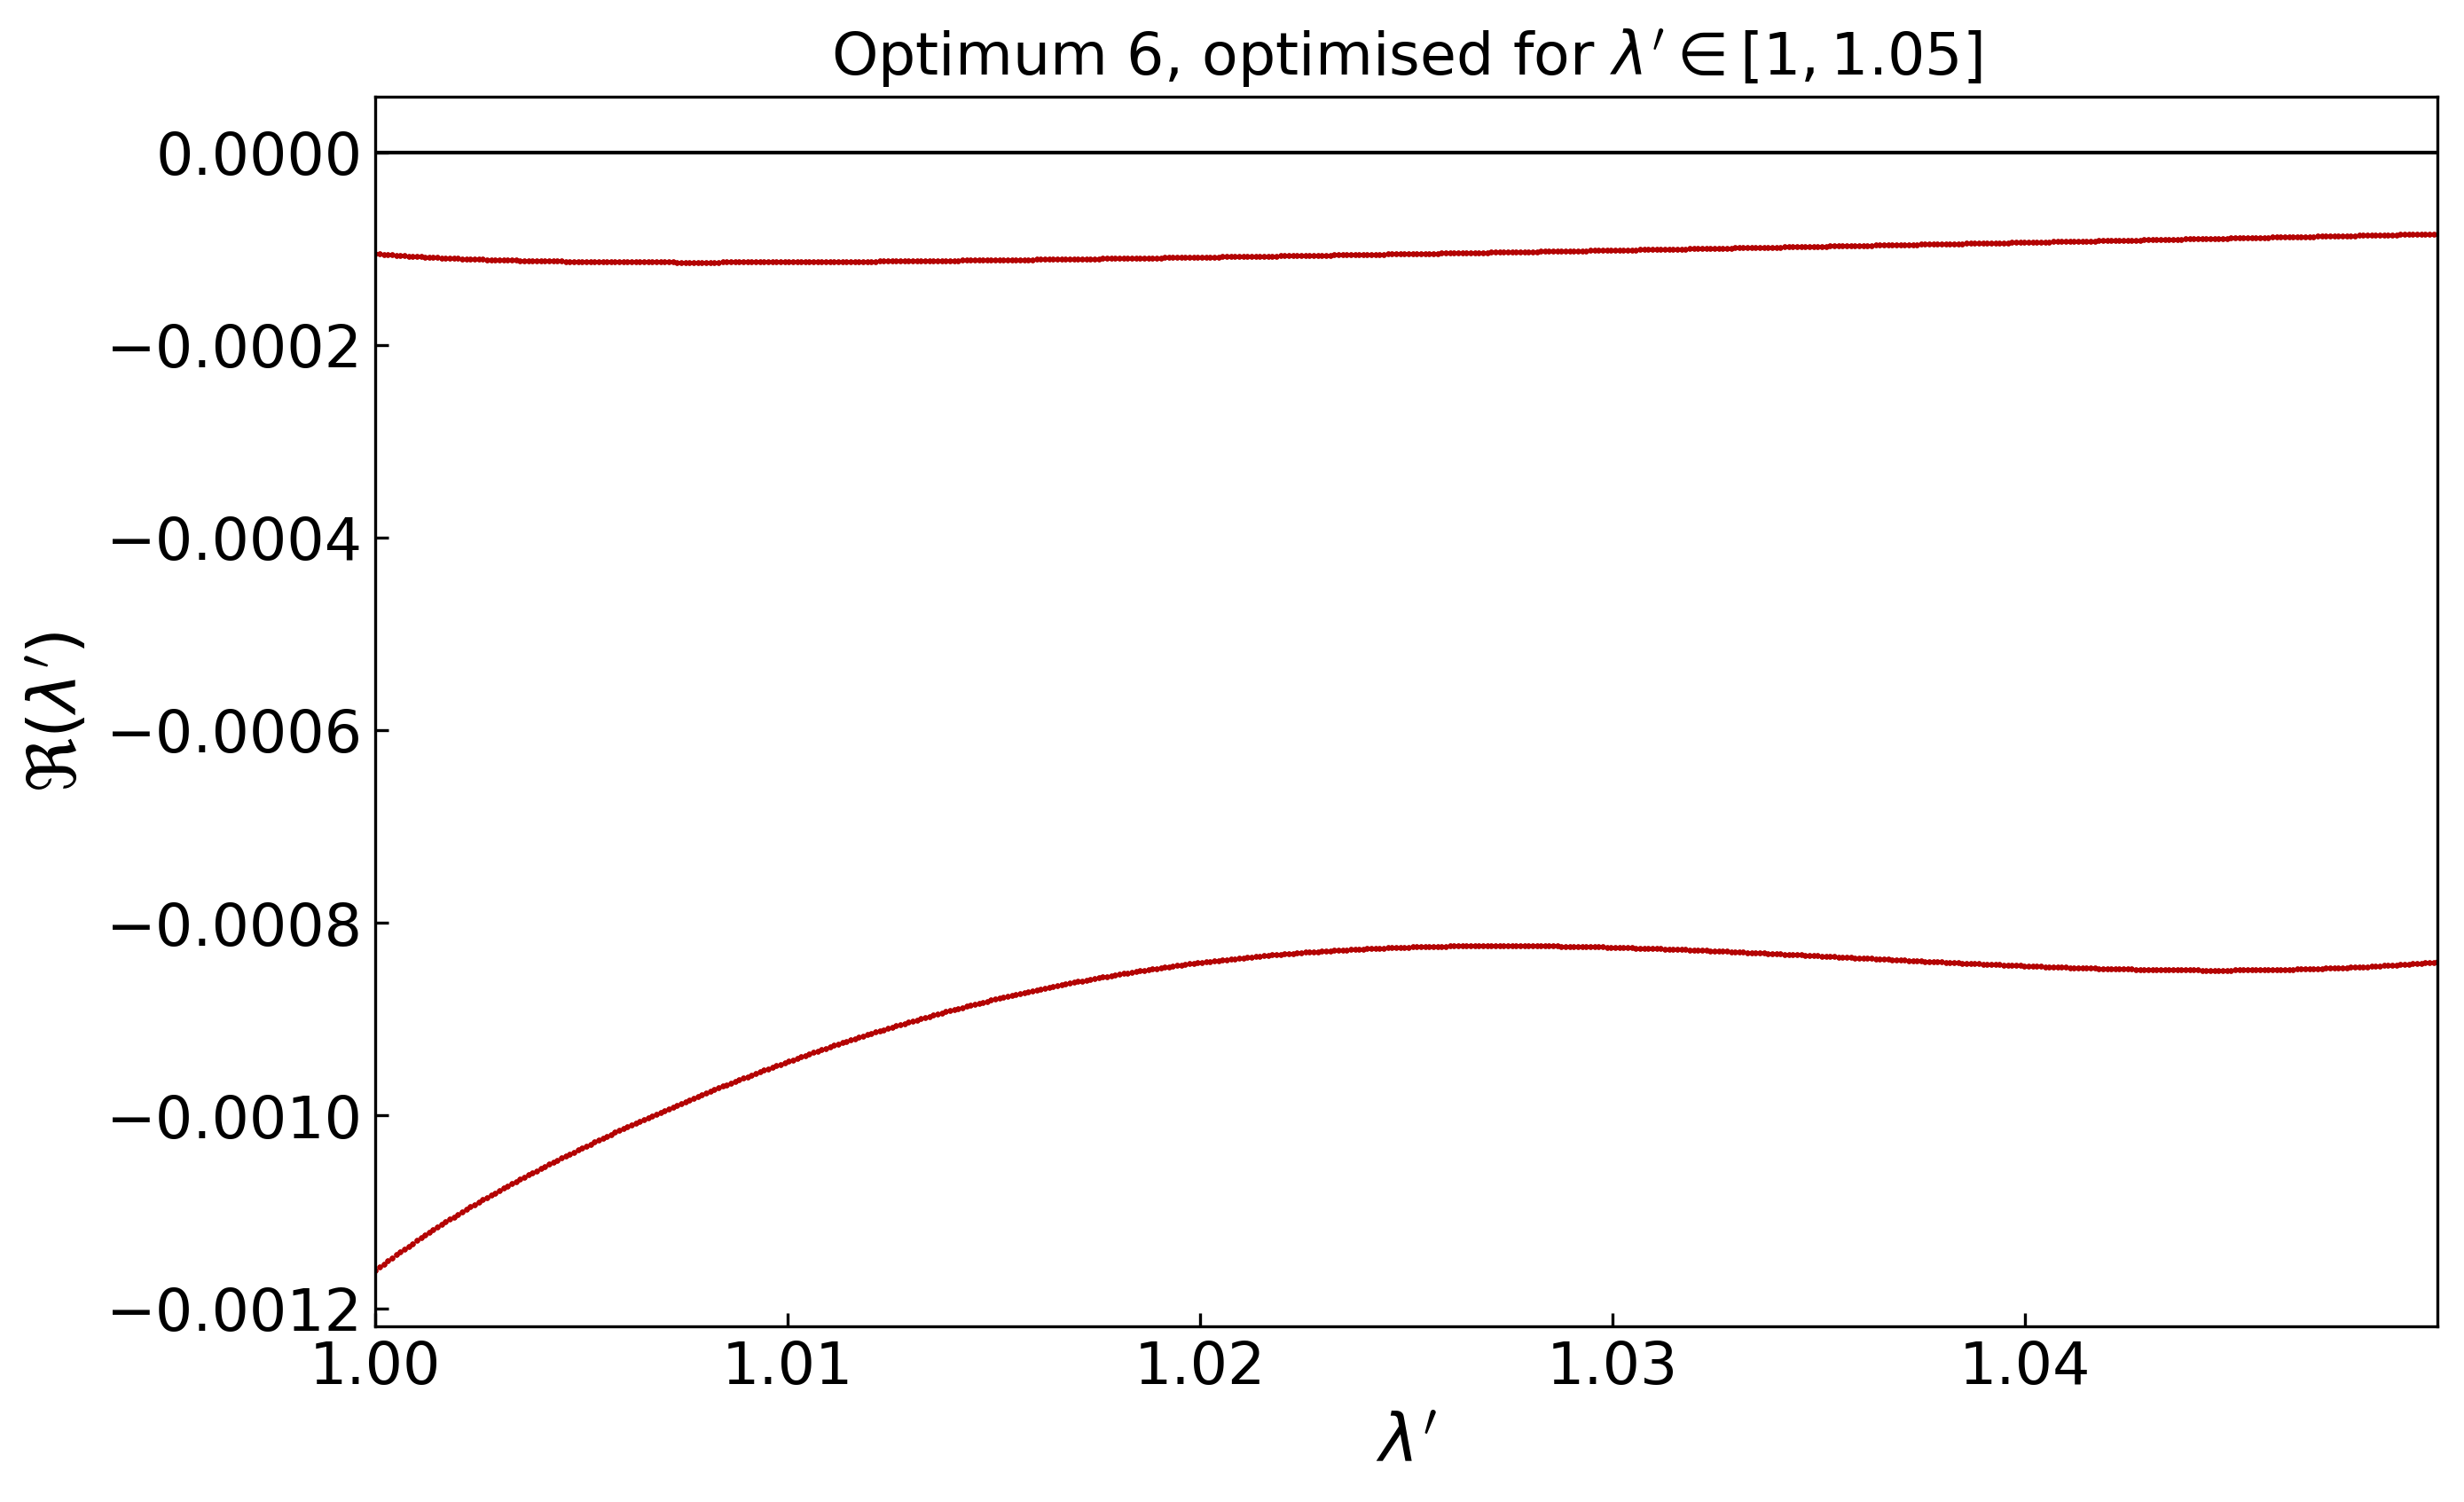

In [10]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(10, 6), nrows=1, ncols=1, dpi = 300)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$")  #color=colorReal  # colored y label
ax1.set(xlabel=r"$\lambda'$")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

ax1.set_title(f"Optimum {optimum_number}, optimised for $\\lambda' \\in [1, 1.05]$")

In [11]:
num_plot_points = 500

grating1 = grating_1.grating
grating2 = grating_2.grating

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating1.wavelength = grating1.npa.array(lam)
    grating2.wavelength = grating2.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating1,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating1.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    stiffnesses = fom.force_coeff(grating2,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J2 = grating2.npa.concatenate((grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals((J1+ J2)/2)
    
grating1.wavelength = init_wavelength
grating2.wavelength = init_wavelength

In [12]:
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()
average_fom

np.float64(0.00012261289345718524)

In [13]:
from matplotlib.lines import Line2D

C:\Users\Shaurya\AppData\Local\Temp\ipykernel_34396\2133565471.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_34396\2133565471.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)


<Figure size 1500x750 with 0 Axes>

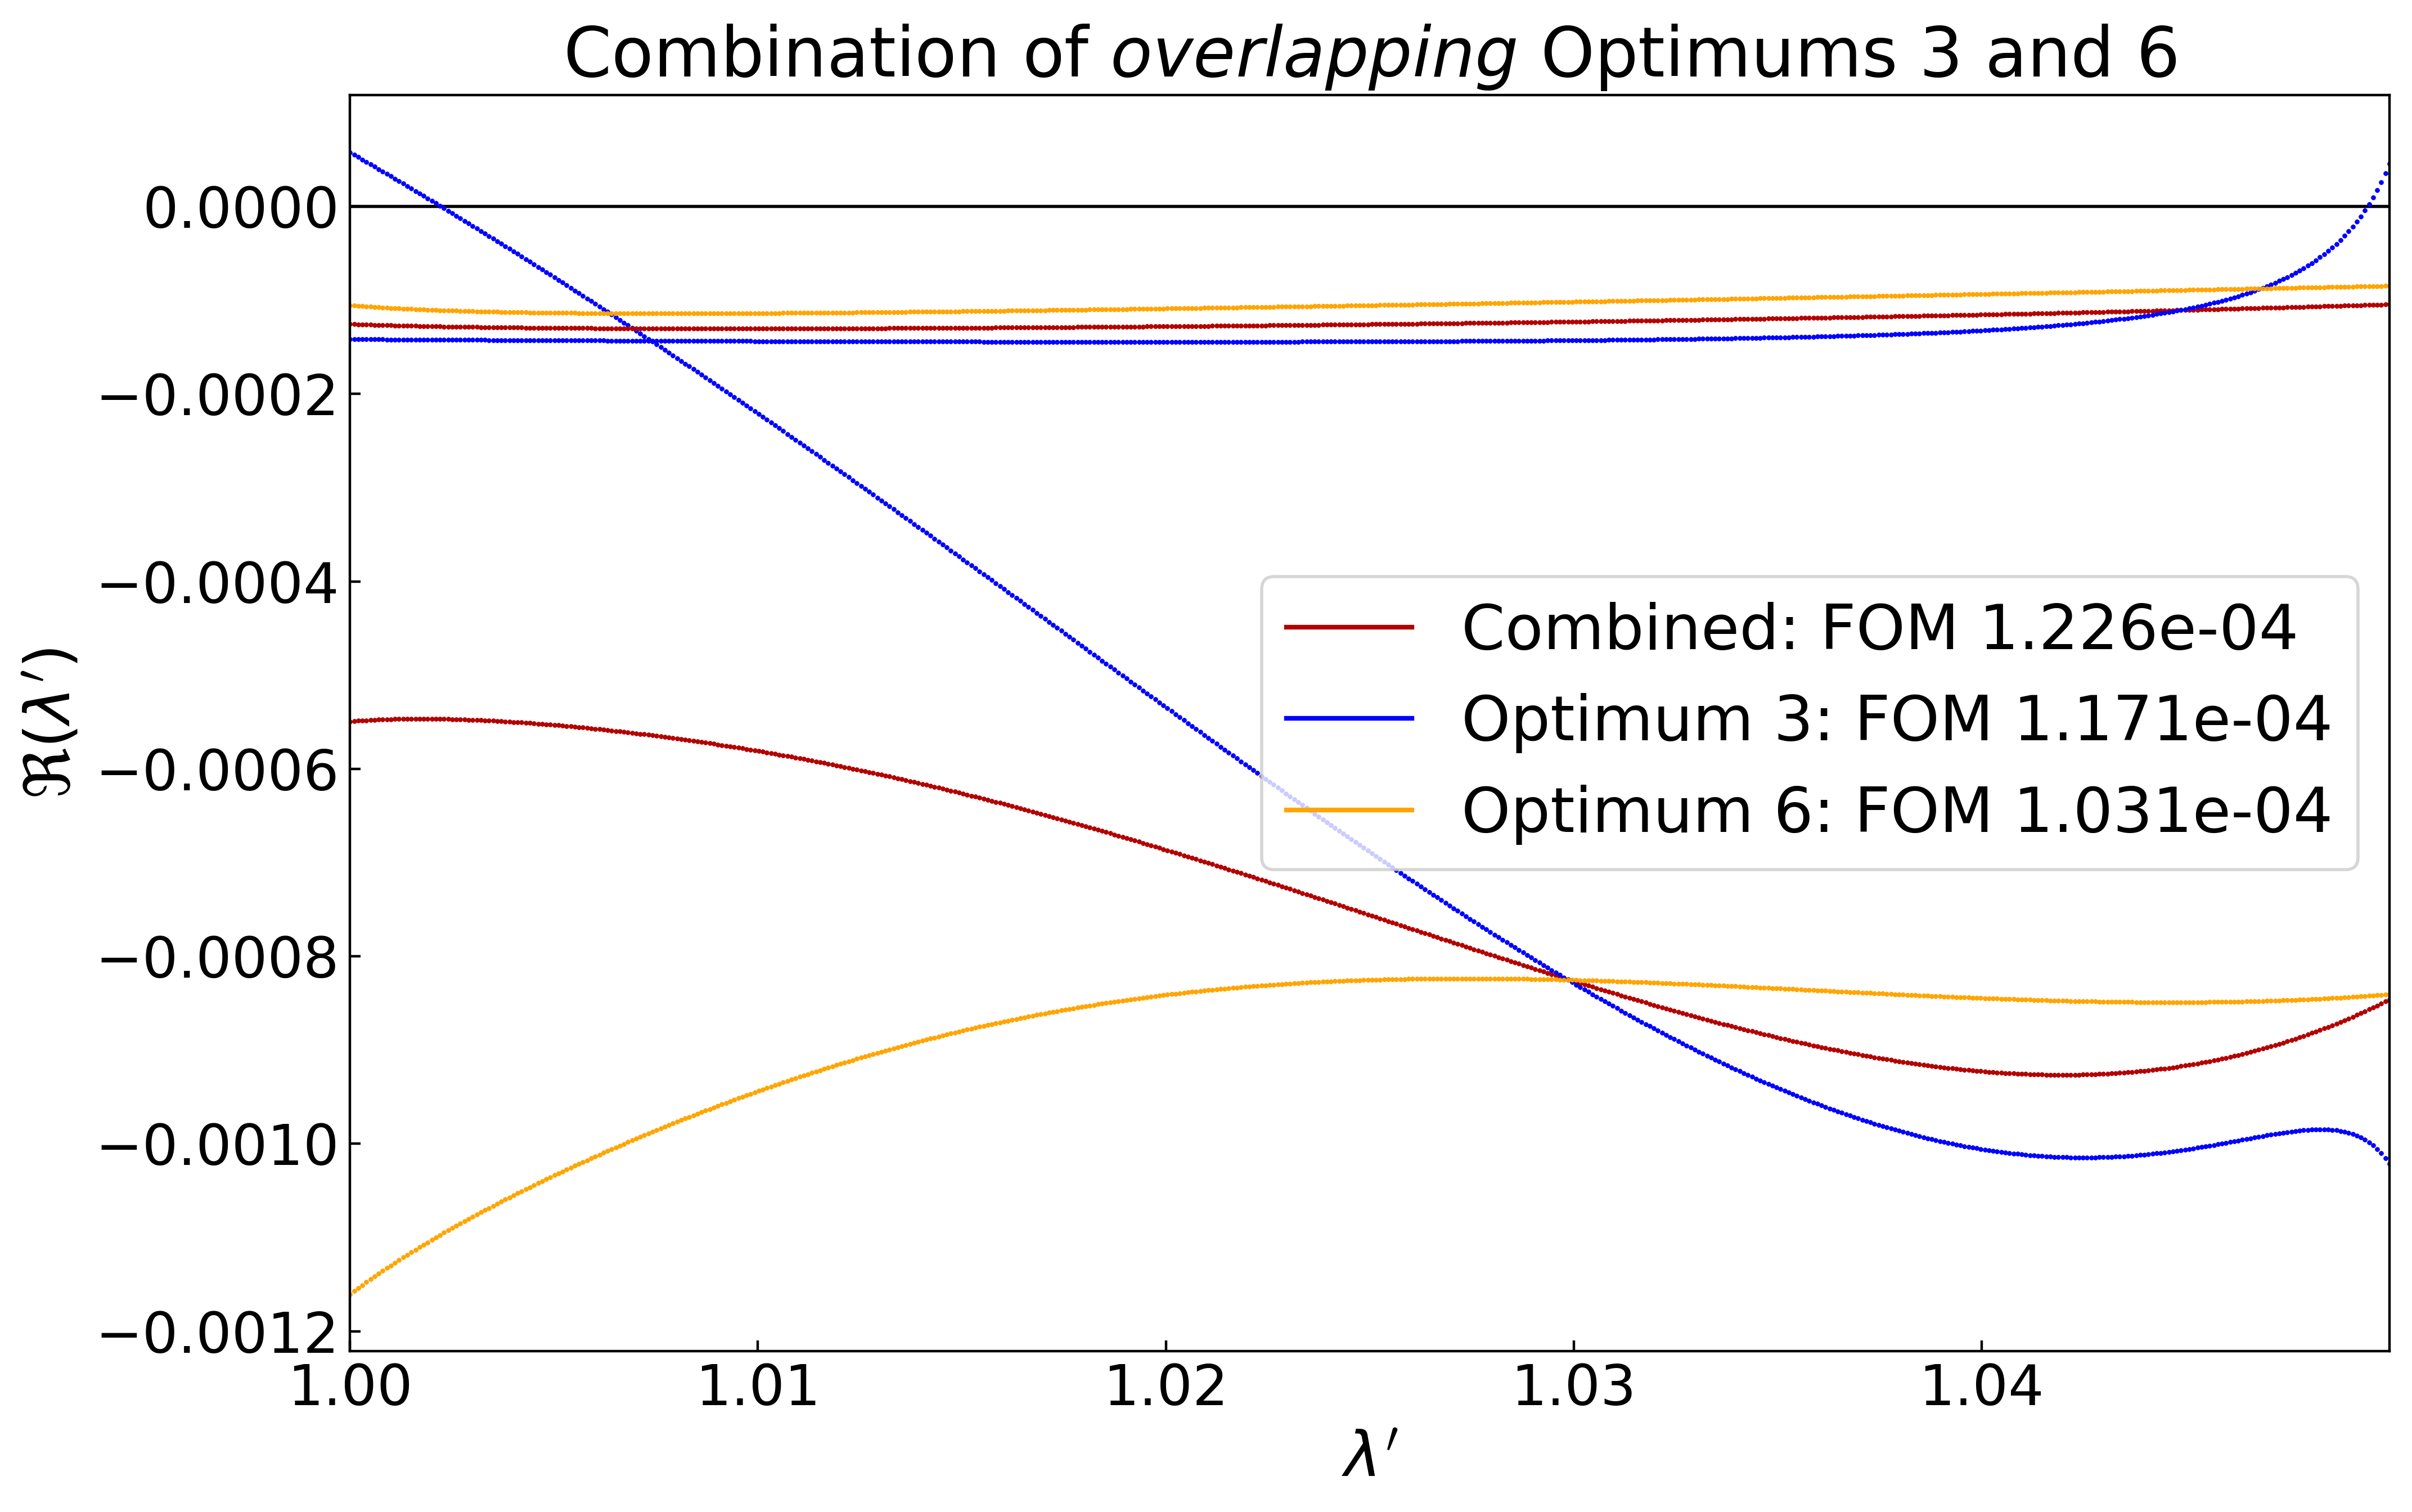

In [14]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(11, 7), nrows=1, ncols=1, dpi = 400)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$", fontsize=20)  #color=colorReal  # colored y label
ax1.set_xlabel(xlabel=r"$\lambda'$", fontsize=20)

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax1.plot(wavelengths,np.real(grating.to_numpy(grating_1.eigvals[i,:])), marker, markersize=0.5, markerfacecolor="blue", fillstyle='full',  color="blue", lw=1)
    ax1.plot(wavelengths,np.real(grating.to_numpy(grating_2.eigvals[i,:])), marker, markersize=0.5, markerfacecolor="orange", fillstyle='full',  color="orange", lw=1)

#ax1.set_ylim((-0.004, 0.004))

legend_elements = [Line2D([0], [0] ,color=colorReal, lw=1.5),
                   Line2D([0], [0], color="blue", lw=1.5),
                   Line2D([0], [0], color="orange", lw=1.5)]


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)

ax1.set_title(f"Combination of $\\it{{overlapping}}$ Optimums 3 and 6", fontsize=22)

fig.tight_layout()
ax1.legend(legend_elements, [f"Combined: FOM {np.format_float_scientific(average_fom, precision=3)}", 
                             f"Optimum 3: FOM {np.format_float_scientific(grating_1.FOM, precision=3)}", 
                             f"Optimum 6: FOM {np.format_float_scientific(grating_2.FOM, precision=3)}"], fontsize=20)

fig.savefig("overlapping_optimums_3_6.png")